In [2]:
import rebound
sim = rebound.Simulation()
sim.add(m=1.)
sim.add(m=1e-3, a=1, e=0.05)
sim.move_to_com()
sim.integrator = "whfast"
sim.dt = 0.05

In [3]:
sim.status()

---------------------------------
REBOUND version:     	4.4.10
REBOUND built on:    	Oct 31 2025 00:46:50
Number of particles: 	2
Selected integrator: 	whfast
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.050000
---------------------------------
<rebound.particle.Particle object at 0x10a5422d0, m=1.0 x=-0.0009490509490509492 y=0.0 z=0.0 vx=0.0 vy=-0.0010507897025075195 vz=0.0>
<rebound.particle.Particle object at 0x10a262830, m=0.001 x=0.949050949050949 y=0.0 z=0.0 vx=0.0 vy=1.0507897025075192 vz=0.0>
---------------------------------
The following fields have non-default values:
dt:
< 1.000000e-03
---
> 5.000000e-02
N:
< 0
---
> 2
integrator:
< 0
---
> 1
rand_seed:
< 608988
---
> 604232
particles:
> (256 bytes, values not printed)



In [4]:
import numpy as np
N_testparticle = 1000
a_initial = np.linspace(1.1, 3, N_testparticle)
for a in a_initial:
    sim.add(a=a,f=np.random.rand()*2.*np.pi) # mass is set to 0 by default, random true anomaly   

In [5]:
t_max = 200.*2.*np.pi
N_out = 10
xy = np.zeros((N_out, N_testparticle, 2))
times = np.linspace(0, t_max, N_out)
for i, time in enumerate(times):
    sim.integrate(time)
    for j, p in enumerate(sim.particles[2:]):
        xy[i][j] = [p.x, p.y]

KeyboardInterrupt: 

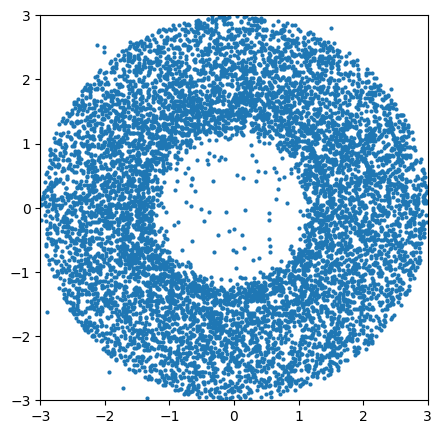

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(5,5))
ax = plt.subplot(111)
ax.set_xlim([-3,3])
ax.set_ylim([-3,3])
plt.scatter(xy[:,:,0],xy[:,:,1],marker=".",linewidth=0)

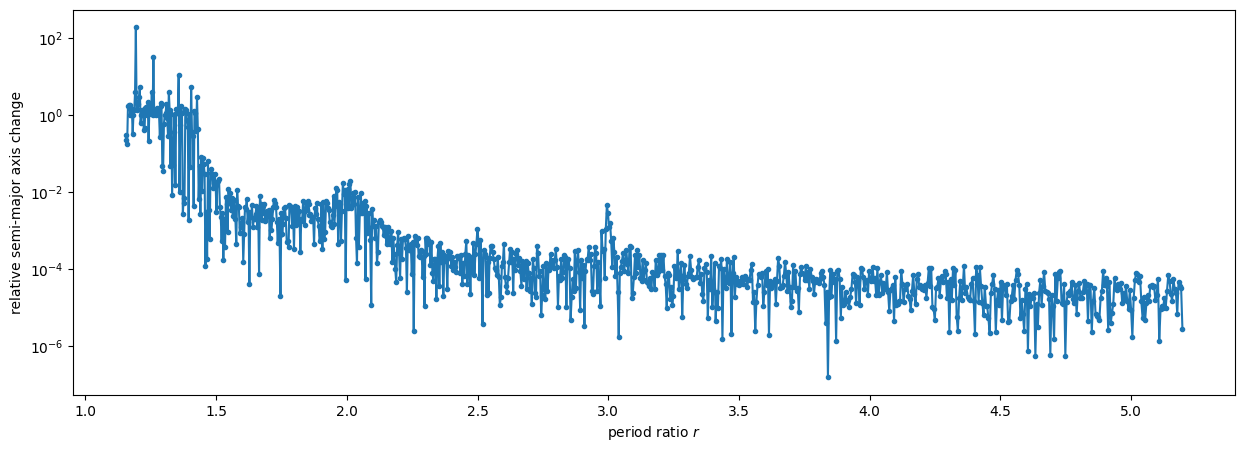

In [ ]:
orbits = sim.orbits()[1:]
a_final = [o.a for o in orbits]
fig = plt.figure(figsize=(15,5))
ax = plt.subplot(111)
ax.set_yscale('log')
ax.set_xlabel(r"period ratio $r$")
ax.set_ylabel("relative semi-major axis change")
plt.plot(np.power(a_initial,1.5),(np.fabs(a_final-a_initial)+1.0e-16)/a_initial,marker=".");

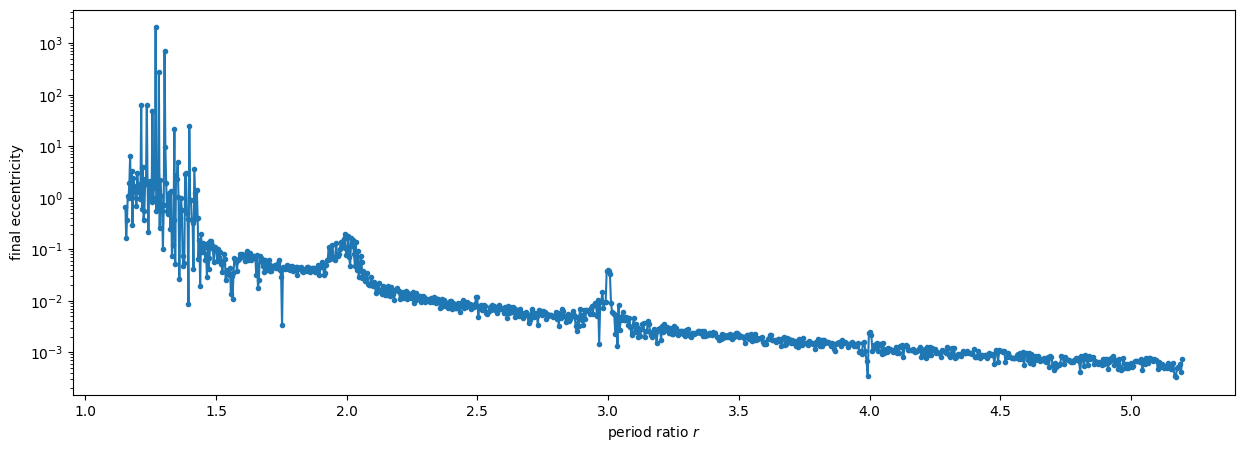

In [ ]:
e_final = np.array([o.e for o in orbits])
fig = plt.figure(figsize=(15,5))
ax = plt.subplot(111)
#ax.set_ylim([0,1])
ax.set_yscale('log')
ax.set_xlabel(r"period ratio $r$")

ax.set_ylabel("final eccentricity")
plt.plot(np.power(a_initial,1.5),e_final+1.0e-16,marker=".");

In [ ]:
print(sim.orbits()[0].a)

0.9999999999999942


In [ ]:
sim = rebound.Simulation()
sim.add(m=1.)
sim.add(m=1e-3, a=1, e=0.05)
sim.move_to_com()
sim.integrator = "whfast"
sim.dt = 0.05
N_testparticle = 1000
a_initial = np.linspace(1.1, 3, N_testparticle)
for a in a_initial:
    sim.add(a=a,f=np.random.rand()*2.*np.pi, m=1e-7)

NameError: name 'rebound' is not defined

In [ ]:
sim.N_active = 2
sim.testparticle_type = 1

In [ ]:
sim.integrate(t_max)
print(sim.orbits()[0].a)

0.9958573539658212


/opt/homebrew/lib/python3.14/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


## REBOUND testing

In [9]:
sim = rebound.Simulation()
sim.add(m=1., hash='star')
sim.add(m=1e-3, a=1, e=0.05, hash='planet')

print(sim.particles[0].hash)

c_uint(3376927956)
